In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image, HTML
from sklearn.model_selection import train_test_split,RandomizedSearchCV
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score

ev3 = pd.read_csv('../../Datasets/evaluacion3.csv')
ev2 = pd.read_csv('../../Datasets/evaluacion2.csv')

In [12]:
def info_df(df):
    return pd.DataFrame({
    'Columna': df.columns,
    'No Nulos': df.notnull().sum().values,
    'Nulos': df.isnull().sum().values,
    'Tipo Python': df.dtypes.values,
    'Núm. valores': [len(df[col].unique()) for col in df.columns]
     })
info = info_df(ev2)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,product_title,7717,0,object,7717
1,product_rating,7717,0,float64,31
2,is_best_seller,7717,0,object,11
3,is_sponsored,7717,0,object,2
4,buy_box_availability,7717,0,int64,2
5,sustainability_tags,7717,0,int64,2
6,has_coupon,7717,0,int64,2
7,discount_percentage,7717,0,float64,72
8,product_category,7717,0,object,19
9,product_segment,7717,0,object,3


In [10]:
ev3.head()

,category,market_tier,condition,is_premium_brand,tech_generation,ram_gb,storage_gb,size_value,performance_value,power_wattage,...,is_best_seller,is_sponsored,buy_box_availability,sustainability_tags,has_coupon,discount_percentage,product_segment,log_original_price,log_purchased_last_month,log_total_reviews
0,PC Components (Core),Mainstream,New,False,Current-Gen,NaN,2048.0,NaN,NaN,NaN,...,No Badge,Sponsored,1,0,0,0.0,Media,5.484755,0.000000,5.883322
1,PC Components (Core),Mainstream,New,False,Current-Gen,NaN,250.0,NaN,NaN,NaN,...,No Badge,Sponsored,1,0,0,0.0,Media,3.783962,0.000000,5.624018
2,Accessories & Consumables,Mainstream,New,False,Current-Gen,NaN,NaN,NaN,NaN,NaN,...,Best Seller,Organic,0,1,0,0.0,Media,3.607941,10.819798,11.523598
3,Accessories & Consumables,Mainstream,New,False,Current-Gen,NaN,NaN,NaN,NaN,NaN,...,No Badge,Organic,0,0,0,0.0,Media,3.804215,10.819798,10.986868
4,Audio & Video Equipment,Mainstream,New,False,Current-Gen,NaN,NaN,NaN,NaN,NaN,...,Best Seller,Organic,0,0,0,0.0,Baja,2.355178,9.210440,11.598433


In [13]:
info = info_df(ev3)
info

,Columna,No Nulos,Nulos,Tipo Python,Núm. valores
0,category,7717,0,object,13
1,market_tier,7714,3,object,5
2,condition,7714,3,object,3
3,is_premium_brand,7714,3,object,3
4,tech_generation,7714,3,object,5
5,ram_gb,626,7091,float64,19
6,storage_gb,853,6864,float64,64
7,size_value,1690,6027,float64,257
8,performance_value,1283,6434,float64,243
9,power_wattage,630,7087,float64,121


## Preparacion de los datos

In [2]:
# ==========================================
# 1. PREPARACIÓN DE DATOS (Target = Log)
# ==========================================

# Definimos columnas
cat_cols = [
    'category', 'market_tier', 'condition', 'is_premium_brand', 
    'tech_generation', 'resolution_standard', 'cpu_gpu_tier', 
    'connectivity', 'brand', 'is_best_seller', 'is_sponsored', 'product_segment'
]

num_cols = [
    'ram_gb', 'storage_gb', 'size_value', 'performance_value', 'power_wattage',
    'pack_count', 'confidence', 'product_rating', 'buy_box_availability',
    'sustainability_tags', 'has_coupon', 'discount_percentage',
    'log_purchased_last_month', 'log_total_reviews'
]

# --- CAMBIO IMPORTANTE: TARGET LOGARÍTMICO ---
target_col = 'log_original_price' 

# Copia y conversión de tipos
df_train = ev3.copy()

for col in cat_cols:
    if col in df_train.columns:
        df_train[col] = df_train[col].astype('category')

# Filtramos columnas existentes
feature_cols = [c for c in cat_cols + num_cols if c in df_train.columns]
X = df_train[feature_cols]
y = df_train[target_col]

# Split 80/20
# 1. Separamos el 20% para TEST (no se toca hasta el final)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 2. Del 80% restante, sacamos un 20% para VALIDACIÓN (que es un 16% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42
)

## Entrenamiento con RandomizedSearch - XGBoost

In [ ]:



# ==========================================
# 2. CONFIGURACIÓN DE RANDOMIZED SEARCH
# ==========================================

param_dist = {
    'max_depth': [6, 7, 8],
    'learning_rate': [0.01, 0.02, 0.05],
    'subsample': [0.5, 0.6, 0.7],
    'colsample_bytree': [0.5, 0.6, 0.7],
    'min_child_weight': [20],
    'gamma': [1, 2, 5],
    'reg_alpha': [1, 5, 10],
    'reg_lambda': [50, 100, 200]
}

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # Optimizamos error cuadrático en el espacio log (equivale a MSLE)
    n_estimators=3000,           # Techo alto, el stop decidirá el final
    tree_method='hist',
    enable_categorical=True,
    early_stopping_rounds=50,    # Si en 50 árboles no mejora el error en val, para
    eval_metric="rmse",          # Métrica para vigilar el stop
    n_jobs=-1,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50, 
    scoring='neg_mean_squared_error', # OJO: Esto será MSE de LOGS (números muy pequeños)
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# ==========================================
# 3. ENTRENAMIENTO
# ==========================================
print("\n🔍 Iniciando búsqueda aleatoria de hiperparámetros...")
random_search.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)], # <--- AQUÍ está el secreto
    verbose=False              # Para que no imprima 3.000 líneas
)

print("\n✅ Búsqueda finalizada.")
print(f"Mejores parámetros: {random_search.best_params_}")




🔍 Iniciando búsqueda aleatoria de hiperparámetros...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

✅ Búsqueda finalizada.
Mejores parámetros: {'subsample': 0.6, 'reg_lambda': 50, 'reg_alpha': 1, 'min_child_weight': 20, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': 0.7}


In [25]:
# ==========================================
# 4. EVALUACIÓN INTEGRAL (TRAIN, VAL, TEST)
# ==========================================

# 1. Obtener el mejor modelo de la búsqueda
best_model = random_search.best_estimator_

# 2. Generar predicciones en escala logarítmica para los 3 conjuntos
p_train_log = best_model.predict(X_train)
p_val_log = best_model.predict(X_val)
p_test_log = best_model.predict(X_test)

# 3. Inversión de la transformación (Log -> Euros reales)
# Usamos expm1 para revertir log1p
p_train_eur = np.expm1(p_train_log)
p_val_eur = np.expm1(p_val_log)
p_test_eur = np.expm1(p_test_log)

y_train_eur = np.expm1(y_train)
y_val_eur = np.expm1(y_val)
y_test_eur = np.expm1(y_test)

# 4. Función auxiliar para calcular métricas
def calcular_metricas(reales, predichos):
    mae = mean_absolute_error(reales, predichos)
    mse = mean_squared_error(reales, predichos)
    rmse = np.sqrt(mse)
    r2 = r2_score(reales, predichos)
    return mae, mse, rmse, r2

# Calcular para cada set
mae_tr, mse_tr, rmse_tr, r2_tr = calcular_metricas(y_train_eur, p_train_eur)
mae_va, mse_va, rmse_va, r2_va = calcular_metricas(y_val_eur, p_val_eur)
mae_te, mse_te, rmse_te, r2_te = calcular_metricas(y_test_eur, p_test_eur)

# ==========================================
# 5. REPORTE FINAL PARA EL TFM
# ==========================================
print("\n" + "="*50)
print("📊 AUDITORÍA DE RENDIMIENTO (Valores en €)")
print("="*50)
print(f"{'Set':<12} | {'MSE (Prioridad)':<15} | {'MAE (€)':<10} | {'R²':<8}")
print("-" * 50)
print(f"{'Train':<12} | {mse_tr:<15.2f} | {mae_tr:<10.2f} | {r2_tr:.4f}")
print(f"{'Validation':<12} | {mse_va:<15.2f} | {mae_va:<10.2f} | {r2_va:.4f}")
print(f"{'Test':<12} | {mse_te:<15.2f} | {mae_te:<10.2f} | {r2_te:.4f}")
print("-" * 50)

# Diagnóstico de Overfitting
diff_overfit = ((mse_te - mse_tr) / mse_tr) * 100
print(f"\n🚩 Análisis de sobreajuste: La diferencia de MSE entre Train y Test es del {diff_overfit:.2f}%")

# Bonus: Ver un ejemplo con Test
comparison = pd.DataFrame({'Real (€)': y_test_eur, 'Predicho (€)': p_test_eur})
comparison['Error (€)'] = comparison['Real (€)'] - comparison['Predicho (€)']
print("\n📌 Muestra de predicciones en datos nuevos (Test):")
print(comparison.head(10).round(2))


📊 AUDITORÍA DE RENDIMIENTO (Valores en €)
Set          | MSE (Prioridad) | MAE (€)    | R²      
--------------------------------------------------
Train        | 67251.00        | 97.53      | 0.6678
Validation   | 69484.09        | 110.92     | 0.5555
Test         | 81831.93        | 112.66     | 0.5600
--------------------------------------------------

🚩 Análisis de sobreajuste: La diferencia de MSE entre Train y Test es del 21.68%

📌 Muestra de predicciones en datos nuevos (Test):
      Real (€)  Predicho (€)  Error (€)
2168     35.99     26.379999       9.61
472     133.99     56.259998      77.73
4159     84.96     78.699997       6.26
676      31.57     27.459999       4.11
6659   1424.00   1439.280029     -15.28
2685    399.00    133.399994     265.60
3185    102.81    168.699997     -65.89
5830    699.99   1293.839966    -593.85
2892     39.99     78.589996     -38.60
3298    377.22    163.570007     213.65


C:\Users\diego\AppData\Local\Temp\ipykernel_9244\2624530437.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')


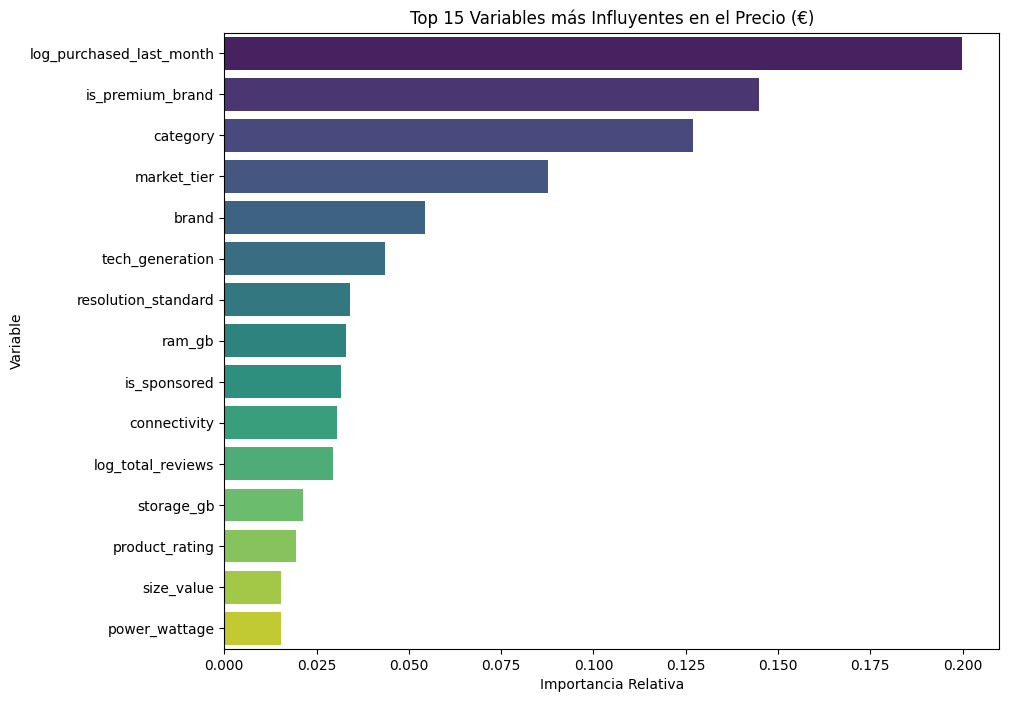

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer importancia
importances = best_model.feature_importances_
feature_names = X.columns

# Crear DataFrame para visualizar
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Graficar
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')
plt.title('Top 15 Variables más Influyentes en el Precio (€)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.show()

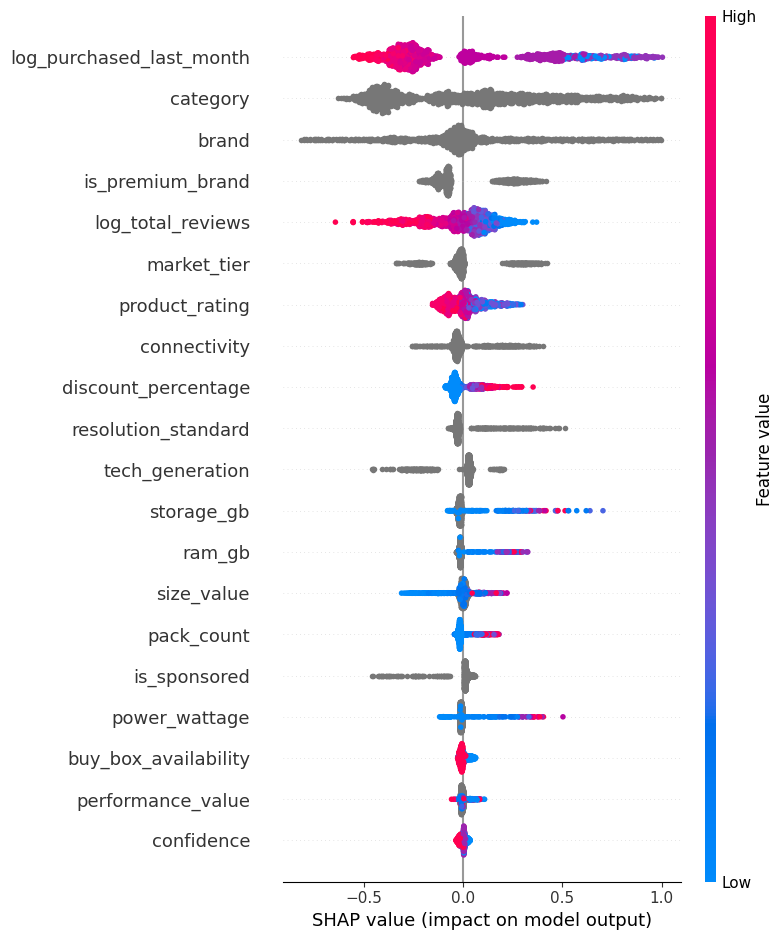

In [27]:
import shap

# 1. Crear el explicador (usamos una muestra de 100 para que sea rápido)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# 2. Gráfico de resumen (Summary Plot)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

## Entrenamiento con Optuna - XGBoost

In [39]:
import optuna
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Preparamos las matrices DMatrix fuera para no repetir el proceso 100 veces
# Esto acelera la optimización considerablemente
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)

def objective(trial):
    # 2. Parámetros para la API Nativa (xgb.train)
    param = {
        'verbosity': 0,
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cpu', # Cambia a 'cuda' si tienes GPU configurada
        
        # Hiperparámetros a optimizar
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 15, 45),
        'subsample': trial.suggest_float('subsample', 0.4, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.9),
        'gamma': trial.suggest_float('gamma', 0.1, 10.0, log=True),
        'alpha': trial.suggest_float('reg_alpha', 1e-3, 50.0, log=True), # L1
        'lambda': trial.suggest_float('reg_lambda', 100.0, 1000.0, log=True), # L2
    }

    # 3. Callback de Poda (Pruning) de Optuna
    # Vigila la métrica 'rmse' que definimos en el evals
    pruning_callback = optuna.integration.XGBoostPruningCallback(trial, "validation-rmse")

    # 4. Entrenamiento con xgb.train (API Nativa)
    evals_result = {}
    model = xgb.train(
        param,
        dtrain,
        num_boost_round=5000,           # Equivalente a n_estimators
        evals=[(dval, 'validation')],   # Datos para validar y podar
        early_stopping_rounds=50,
        verbose_eval=False,
        callbacks=[pruning_callback]
    )

    # 5. Extraer el mejor score de validación
    # model.best_score es el RMSE en escala logarítmica
    return model.best_score

# --- Lanzar la optimización ---
study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\n🏆 Mejores parámetros: {study.best_params}")

[I 2026-02-06 12:10:27,991] A new study created in memory with name: no-name-30f36e08-5ad4-422b-98a7-b4bafb09d4bc


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-02-06 12:10:29,087] Trial 0 finished with value: 0.7365803656084159 and parameters: {'learning_rate': 0.044341047290290266, 'max_depth': 7, 'min_child_weight': 36, 'subsample': 0.4125850575898377, 'colsample_bytree': 0.8455760867524595, 'gamma': 1.8042197315577388, 'reg_alpha': 1.0907692433778364, 'reg_lambda': 173.6677854877425}. Best is trial 0 with value: 0.7365803656084159.
[I 2026-02-06 12:10:31,515] Trial 1 finished with value: 0.7064280583837729 and parameters: {'learning_rate': 0.04046250233202049, 'max_depth': 9, 'min_child_weight': 30, 'subsample': 0.5725392432081609, 'colsample_bytree': 0.6686716777420271, 'gamma': 0.15359437012655391, 'reg_alpha': 0.007869177012035447, 'reg_lambda': 930.3101023268828}. Best is trial 1 with value: 0.7064280583837729.
[I 2026-02-06 12:10:34,073] Trial 2 finished with value: 0.7540179957186638 and parameters: {'learning_rate': 0.012943814941535427, 'max_depth': 5, 'min_child_weight': 41, 'subsample': 0.5329197732713888, 'colsample_bytr

In [40]:
# --- PASO 1: Entrenar el modelo ganador con los mejores parámetros ---
print("🏗️ Entrenando modelo final con los mejores parámetros de Optuna...")

# Recuperamos los parámetros de Optuna
final_params = study.best_params
final_params['objective'] = 'reg:squarederror'
final_params['tree_method'] = 'hist'
# Asegúrate de habilitar categorías si usas la API nativa
final_params['enable_categorical'] = True 

# Creamos las DMatrix (si no las tienes ya creadas del paso anterior)
dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True)
dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True)

# Entrenamos el modelo final
best_model_final = xgb.train(
    final_params,
    dtrain,
    num_boost_round=5000,
    evals=[(dval, 'validation')],
    early_stopping_rounds=50,
    verbose_eval=False
)

# --- PASO 2: Predicciones (Escala Log) ---
p_train_log = best_model_final.predict(dtrain)
p_val_log = best_model_final.predict(dval)
p_test_log = best_model_final.predict(dtest)

# --- PASO 3: Inversión a Euros (€) ---
p_train_eur = np.expm1(p_train_log)
p_val_eur = np.expm1(p_val_log)
p_test_eur = np.expm1(p_test_log)

y_train_eur = np.expm1(y_train)
y_val_eur = np.expm1(y_val)
y_test_eur = np.expm1(y_test)

# --- PASO 4: Cálculo de Métricas ---
def get_metrics(reales, predichos):
    mse = mean_squared_error(reales, predichos)
    mae = mean_absolute_error(reales, predichos)
    r2 = r2_score(reales, predichos)
    return mse, mae, r2

mse_tr, mae_tr, r2_tr = get_metrics(y_train_eur, p_train_eur)
mse_va, mae_va, r2_va = get_metrics(y_val_eur, p_val_eur)
mse_te, mae_te, r2_te = get_metrics(y_test_eur, p_test_eur)

# --- PASO 5: Reporte Final ---
print("\n" + "="*60)
print("📊 RESULTADOS FINALES OPTUNA (Valores en €)")
print("="*60)
print(f"{'Set':<12} | {'MSE (Prioridad)':<15} | {'MAE (€)':<10} | {'R²':<8}")
print("-" * 60)
print(f"{'Train':<12} | {mse_tr:<15.2f} | {mae_tr:<10.2f} | {r2_tr:.4f}")
print(f"{'Validation':<12} | {mse_va:<15.2f} | {mae_va:<10.2f} | {r2_va:.4f}")
print(f"{'Test':<12} | {mse_te:<15.2f} | {mae_te:<10.2f} | {r2_te:.4f}")
print("-" * 60)

# Diagnóstico de Sobreajuste
overfit_final = ((mse_te - mse_tr) / mse_tr) * 100
print(f"🚩 Diferencia de error Train/Test: {overfit_final:.2f}%")

# Ejemplo de Predicciones
comparison = pd.DataFrame({'Real': y_test_eur, 'Predicho': p_test_eur})
comparison['Error'] = comparison['Real'] - comparison['Predicho']
print("\n📌 Muestra de predicciones en Test:")
print(comparison.head(10).round(2))

🏗️ Entrenando modelo final con los mejores parámetros de Optuna...

📊 RESULTADOS FINALES OPTUNA (Valores en €)
Set          | MSE (Prioridad) | MAE (€)    | R²      
------------------------------------------------------------
Train        | 44700.99        | 75.74      | 0.7792
Validation   | 62016.02        | 107.22     | 0.6033
Test         | 76144.68        | 105.87     | 0.5906
------------------------------------------------------------
🚩 Diferencia de error Train/Test: 70.34%

📌 Muestra de predicciones en Test:
         Real     Predicho   Error
2168    35.99    18.629999   17.36
472    133.99    56.349998   77.64
4159    84.96    96.199997  -11.24
676     31.57    16.160000   15.41
6659  1424.00  1286.180054  137.82
2685   399.00   177.699997  221.30
3185   102.81   173.589996  -70.78
5830   699.99  1179.510010 -479.52
2892    39.99    83.430000  -43.44
3298   377.22   201.550003  175.67


## Entrenamiento con Optuna - CatBoost

In [4]:
import optuna
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Identificar índices de columnas categóricas (CatBoost lo necesita)
for col in cat_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype(str).replace('nan', 'None')
        X_val[col] = X_val[col].astype(str).replace('nan', 'None')
        X_test[col] = X_test[col].astype(str).replace('nan', 'None')

# Importante: Como hemos convertido a string, volvemos a obtener los índices
# por si el orden de las columnas ha cambiado (aunque no debería)
cat_features_indices = [X_train.columns.get_loc(c) for c in cat_cols if c in X_train.columns]

def objective(trial):
    param = {
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "task_type": "CPU", # Cambia a "GPU" si tienes una disponible
        "verbose": False,
        "random_seed": 42,
        
        # Hiperparámetros a optimizar
        "iterations": 3000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 50.0),
        "random_strength": trial.suggest_float("random_strength", 1.0, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "od_type": "Iter",
        "od_wait": 50, # Early stopping interno
    }

    model = CatBoostRegressor(**param)
    
    # Entrenamiento
    model.fit(
        X_train, y_train,
        cat_features=cat_features_indices,
        eval_set=(X_val, y_val),
        early_stopping_rounds=50
    )

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

# --- Ejecutar el estudio ---
study_cat = optuna.create_study(direction="minimize")
study_cat.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"🏆 Mejores parámetros CatBoost: {study_cat.best_params}")

[I 2026-02-06 12:41:44,702] A new study created in memory with name: no-name-74ba20cf-a260-4f3e-af23-760ae663b32e


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-02-06 12:42:09,846] Trial 0 finished with value: 0.6691839004537611 and parameters: {'learning_rate': 0.09676161758160386, 'depth': 8, 'l2_leaf_reg': 2.1530373997654957, 'random_strength': 7.249246212158998, 'bagging_temperature': 0.6222222538442098, 'border_count': 245}. Best is trial 0 with value: 0.6691839004537611.
[I 2026-02-06 12:42:26,130] Trial 1 finished with value: 0.6659483483515762 and parameters: {'learning_rate': 0.09566356284966807, 'depth': 6, 'l2_leaf_reg': 18.320265199277866, 'random_strength': 6.355106873415701, 'bagging_temperature': 0.6112998842642423, 'border_count': 53}. Best is trial 1 with value: 0.6659483483515762.
[I 2026-02-06 12:45:27,845] Trial 2 finished with value: 0.6671732388015094 and parameters: {'learning_rate': 0.018628756701167534, 'depth': 9, 'l2_leaf_reg': 46.27272673792368, 'random_strength': 7.4545983467519665, 'bagging_temperature': 0.25034978221849813, 'border_count': 255}. Best is trial 1 with value: 0.6659483483515762.
[I 2026-02-0

In [5]:
# Entrenar modelo final
best_params_cat = study_cat.best_params
best_params_cat.update({
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 5000,
    "random_seed": 42
})

final_cat_model = CatBoostRegressor(**best_params_cat)
final_cat_model.fit(
    X_train, y_train,
    cat_features=cat_features_indices,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50,
    verbose=100
)

# Predicciones y transformación inversa
def evaluate_cat(model, X, y_true_log):
    p_log = model.predict(X)
    p_eur = np.expm1(p_log)
    y_eur = np.expm1(y_true_log)
    
    mse = mean_squared_error(y_eur, p_eur)
    mae = mean_absolute_error(y_eur, p_eur)
    r2 = r2_score(y_eur, p_eur)
    return mse, mae, r2

mse_tr, mae_tr, r2_tr = evaluate_cat(final_cat_model, X_train, y_train)
mse_va, mae_va, r2_va = evaluate_cat(final_cat_model, X_val, y_val)
mse_te, mae_te, r2_te = evaluate_cat(final_cat_model, X_test, y_test)

print("\n" + "="*50)
print("📊 RESULTADOS FINALES CATBOOST (€)")
print("="*50)
print(f"{'Set':<12} | {'MSE':<15} | {'MAE (€)':<10} | {'R²':<8}")
print("-" * 50)
print(f"{'Train':<12} | {mse_tr:<15.2f} | {mae_tr:<10.2f} | {r2_tr:.4f}")
print(f"{'Validation':<12} | {mse_va:<15.2f} | {mae_va:<10.2f} | {r2_va:.4f}")
print(f"{'Test':<12} | {mse_te:<15.2f} | {mae_te:<10.2f} | {r2_te:.4f}")
print("-" * 50)

0:	learn: 1.2915204	test: 1.2940622	best: 1.2940622 (0)	total: 79ms	remaining: 6m 35s
100:	learn: 0.7727094	test: 0.7690519	best: 0.7690409 (99)	total: 4.24s	remaining: 3m 25s
200:	learn: 0.7160740	test: 0.7324485	best: 0.7324485 (200)	total: 8.26s	remaining: 3m 17s
300:	learn: 0.6276974	test: 0.6907927	best: 0.6907927 (300)	total: 13.3s	remaining: 3m 27s
400:	learn: 0.5775865	test: 0.6774949	best: 0.6774239 (399)	total: 18.1s	remaining: 3m 27s
500:	learn: 0.5415904	test: 0.6709322	best: 0.6709322 (500)	total: 23s	remaining: 3m 26s
600:	learn: 0.5131669	test: 0.6664496	best: 0.6664496 (600)	total: 28.1s	remaining: 3m 25s
700:	learn: 0.4866347	test: 0.6611288	best: 0.6611288 (700)	total: 33.4s	remaining: 3m 24s
800:	learn: 0.4693167	test: 0.6587459	best: 0.6587459 (800)	total: 38.5s	remaining: 3m 21s
900:	learn: 0.4542359	test: 0.6579501	best: 0.6579412 (889)	total: 43.3s	remaining: 3m 17s
1000:	learn: 0.4383449	test: 0.6560427	best: 0.6560167 (996)	total: 48.3s	remaining: 3m 12s
1100:	

C:\Users\diego\AppData\Local\Temp\ipykernel_2816\32657623.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')


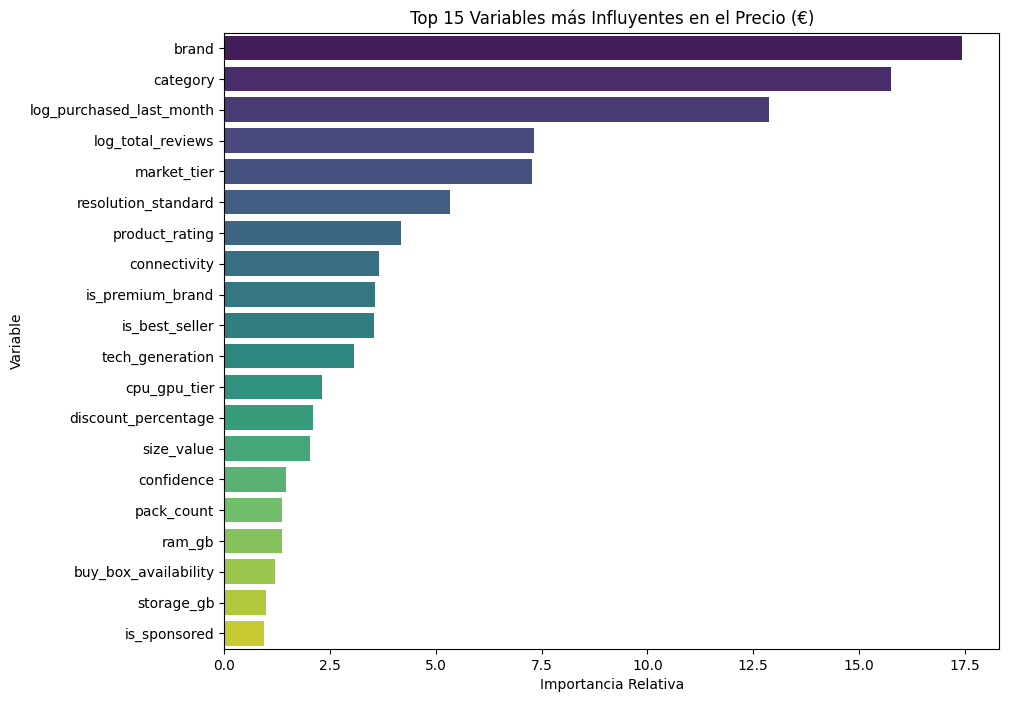

In [7]:
# Extraer importancia
importances = final_cat_model.feature_importances_
feature_names = X.columns

# Crear DataFrame para visualizar
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Graficar
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 15 Variables más Influyentes en el Precio (€)')
plt.xlabel('Importancia Relativa')
plt.ylabel('Variable')
plt.show()